<a href="https://colab.research.google.com/github/WVF-1/FULPs-Framework-CA-Application/blob/main/FULPs_CA_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs CA — v4
**Confidence-Gated Asynchronous Updates: From Adaptive Learning to Adaptive Participation**

Author: William V. Fullerton  
Conscientiâ Research Group

---

### What changed from v3

| Component | v3 | v4 | Reason |
|-----------|----|----|--------|
| Timesteps | 150 | 200 | Longer stable windows; more post-perturb recovery time |
| T_PERTURB | 75 | 100 | Centred in 200-timestep run |
| N_RUNS | 30 | 50 | Stronger statistical evidence for novel mechanism |
| Conditions | 2 (FULPs vs Baseline) | 3 (base / learn / gate) | Isolates gating contribution |
| Confidence gating | None | Active | v4 core mechanism |
| STABLE_MAX_CHANGES | 7 | 10 | Proportional to 199 transitions |
| Measurement windows | Pre/post adjacent | Pre t=50-99, Post t=150-199 | 50-step recovery buffer after perturbation |

### Everything preserved from v3
- IDF priors, VoidStabilizer, EA, VT — all unchanged
- `BASE_THRESHOLD=0.70`, `CONTRA_THRESHOLD=0.60`, `CONF_GATE=0.60`
- Dynamic ARE threshold `0.20→0.05`, `BUFFER_DELAY=10`, `EMA_ALPHA=0.1`, `CURIOSITY_WEIGHT=2.0`
- Perturbation: {2,3}→{2,3,4} survival, 70 affected states
- Per-condition recovery tracking, contradiction spike, per-state accuracy

### Three-Condition Architecture

| Condition | Grid dynamics | Table | ARE | Gating |
|-----------|--------------|-------|-----|--------|
| **base** | Standard synchronous GoL | Uniform weights | None | None |
| **learn** | Standard synchronous GoL | FULPs (ARE-weighted) | Active | None |
| **gate** | Confidence-gated GoL | FULPs (ARE-weighted) | Active | Active |

Note: base and learn share identical grid dynamics. Only gate diverges.
This isolates gating as the specific ingredient that changes population behaviour.

### The Gating Rule
A FULPs cell defers its state transition (holds current state for one tick) when:
1. It has observed its current neighbourhood state **≥ 2 times** (has genuine evidence)
2. Its survival probability for that state falls in the **uncertainty band**: p ∈ (0.30, 0.70)
3. The previous rule has been removed in favor of a simplar determistic approache, as the previous was pushing out the real values and not firing the gate proper, if at all

**Critical design principle (central to FULPs):** ARE buffer updates continue regardless
of gating. Cells accumulate evidence even while deferring action. Confidence gating and
learning are separated — a cell observes before it commits.

### Primary Metric: Population Coefficient of Variation (CV)
CV = std(population) / mean(population) in a measurement window.  
Lower CV = more stable population dynamics.  
Pre-window: t=50–99. Post-window: t=150–199 (50-step recovery buffer after t=100 perturbation).

### Five Diagnostic Layers
1. **Infrastructure** — DSC, VT, coverage, online accuracy (carried from v1–v3)
2. **Perturbation** — spike, affected-state drop, recovery (carried from v3)
3. **Gating mechanism** — Is gating active? Does it spike at perturbation?
4. **Dynamic divergence** — Do gated and standard grids actually diverge?
5. **Novelty verdict** — Is gate more stable than learn? Is gate more stable than base?

### Paper Notes
- v3 correlation contradiction→performance (r=0.791) bridges to v4: the mechanism most
  coupled to performance is now the one that gates behaviour
- The gating mechanism operationalises the FULPs survival imperative behaviourally:
  a cell does not commit to a potentially fatal state change when it lacks confident evidence
- Stability improvement is emergent, not designed — no inter-cell communication, no
  global coordination. Each cell acts only on locally available information

In [1]:
# ── Cell 1: Install ──────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy', '--quiet'])
print('Done.')

Done.


In [2]:
# ── Cell 2: Imports and Configuration ────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.linalg import cholesky
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# ── Grid ──────────────────────────────────────────────────────────────────────
GRID_H       = 50
GRID_W       = 50
N_TIMESTEPS  = 200
T_PERTURB    = 100

# ── Measurement windows ───────────────────────────────────────────────────────
PRE_WIN_START,  PRE_WIN_END  = 50,  100   # 50-step pre-perturb stable window
POST_WIN_START, POST_WIN_END = 150, 200   # 50-step post-perturb window (50-step buffer)
COLLAPSE_THRESHOLD           = 50         # population < 50 = collapse event

# ── Neighbourhood ─────────────────────────────────────────────────────────────
NBR_DIM  = 9
N_STATES = 512

# ── VoidStabilizer (preserved from v4/v1/v2/v3) ───────────────────────────────
VOID_HIDDEN   = 16
EA_TARGET_STD = 0.3
EA_WEIGHT     = 0.5
VOID_EPOCHS   = 100
VOID_BATCH    = 256

# ── Void Tether ───────────────────────────────────────────────────────────────
VT_WEIGHT     = 0.05

# ── ARE (preserved; CONF_GATE=0.60 ablation-confirmed) ────────────────────────
CONTRA_START     = 0.20
CONTRA_END       = 0.05
CONF_GATE        = 0.60
BUFFER_DELAY     = 10
EMA_ALPHA        = 0.1
CURIOSITY_WEIGHT = 2.0

# ── Prediction thresholds (ablation-confirmed) ────────────────────────────────
BASE_THRESHOLD   = 0.70
CONTRA_THRESHOLD = 0.60

# ── v4 Gating parameters ──────────────────────────────────────────────────────
# Gating fires when p_survive ∈ (GATE_LOW, GATE_HIGH) AND visits >= GATE_MIN_VISITS
# Aligned with documentation: uncertainty band p in (0.30, 0.70)
GATE_LOW        = 1.0 - BASE_THRESHOLD # 0.30
GATE_HIGH       = BASE_THRESHOLD       # 0.70
GATE_MIN_VISITS = 2                       # minimum observations before gating activates
UNCERTAINTY_SLOWDOWN_FACTOR = 0.5         # New: Factor to reduce learning rate for uncertain cells

# ── Stability ─────────────────────────────────────────────────────────────────
STABLE_MAX_CHANGES = 10    # ≤10/199 transitions = ~5% change rate

# ── Contradiction spike windows ───────────────────────────────────────────────
SPIKE_PRE_START  = T_PERTURB - 10
SPIKE_PRE_END    = T_PERTURB
SPIKE_POST_START = T_PERTURB + 1
SPIKE_POST_END   = T_PERTURB + 11

# ── Gating spike windows ──────────────────────────────────────────────────────
GATE_SPIKE_PRE_START  = T_PERTURB - 10
GATE_SPIKE_PRE_END    = T_PERTURB
GATE_SPIKE_POST_START = T_PERTURB + 1
GATE_SPIKE_POST_END   = T_PERTURB + 11

# ── Multi-run ─────────────────────────────────────────────────────────────────
N_RUNS     = 50
BATCH_SIZE = 5
BASE_SEED  = 42
OUT_DIR    = '/content'

# ── Derived ───────────────────────────────────────────────────────────────────
REP_DIM = VOID_HIDDEN

print('Configuration ready.')
print(f'  Grid: {GRID_H}x{GRID_W}  |  Timesteps: {N_TIMESTEPS}  |  T_PERTURB: {T_PERTURB}')
print(f'  PRE window:  t={PRE_WIN_START}-{PRE_WIN_END-1}')
print(f'  POST window: t={POST_WIN_START}-{POST_WIN_END-1}  (50-step recovery buffer)')
print(f'  Gating band: p_survive in ({GATE_LOW:.2f}, {GATE_HIGH:.2f})  min_visits={GATE_MIN_VISITS}')
print(f'  CONF_GATE={CONF_GATE}  BASE_THRESHOLD={BASE_THRESHOLD}  CONTRA_THRESHOLD={CONTRA_THRESHOLD}')
print(f'  Multi-run: {N_RUNS} runs (seeds {BASE_SEED}-{BASE_SEED+N_RUNS-1}), batch every {BATCH_SIZE}')

Configuration ready.
  Grid: 50x50  |  Timesteps: 200  |  T_PERTURB: 100
  PRE window:  t=50-99
  POST window: t=150-199  (50-step recovery buffer)
  Gating band: p_survive in (0.30, 0.70)  min_visits=2
  CONF_GATE=0.6  BASE_THRESHOLD=0.7  CONTRA_THRESHOLD=0.6
  Multi-run: 50 runs (seeds 42-91), batch every 5


In [3]:
# ── Cell 3: Conway's Game of Life (unchanged from v3) ────────────────────────
def tick(grid, perturbed=False):
    H, W = grid.shape
    nbr_count = np.zeros((H, W), dtype=np.int8)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0: continue
            nbr_count += np.roll(np.roll(grid, di, axis=0), dj, axis=1)
    next_grid = np.zeros((H, W), dtype=np.int8)
    alive = grid == 1
    if perturbed:
        next_grid[alive  & ((nbr_count==2)|(nbr_count==3)|(nbr_count==4))] = 1
    else:
        next_grid[alive  & ((nbr_count==2)|(nbr_count==3))] = 1
    next_grid[~alive & (nbr_count==3)] = 1
    return next_grid

def population(grid): return int(grid.sum())

_test = np.zeros((10,10), dtype=np.int8)
_test[1,2]=_test[2,3]=_test[3,1]=_test[3,2]=_test[3,3]=1
assert population(tick(_test))==5, 'Glider FAIL'
_t2 = np.zeros((5,5), dtype=np.int8)
_t2[2,2]=_t2[1,2]=_t2[3,2]=_t2[2,1]=_t2[2,3]=1
assert tick(_t2)[2,2]==0 and tick(_t2,True)[2,2]==1, 'Perturb rule FAIL'
print("GoL defined (toroidal, perturbed variant). Sanity checks: PASS")

GoL defined (toroidal, perturbed variant). Sanity checks: PASS


In [4]:
# ── Cell 4: IDF (unchanged from v1-v3) ───────────────────────────────────────
class InnerDepthField:
    def __init__(self, seq_len=NBR_DIM):
        self.seq_len = seq_len
    def _corr_matrix(self, rho):
        idx = np.arange(self.seq_len)
        return rho**np.abs(idx[:,None]-idx[None,:]) + np.eye(self.seq_len)*1e-6
    def sample(self, n):
        X = np.zeros((n, self.seq_len))
        for i in range(n):
            mu  = np.random.normal(0, 0.02)
            sig = np.random.uniform(0.05, 0.30)
            rho = np.random.uniform(-0.2, 0.2)
            try:
                L = cholesky(self._corr_matrix(rho), lower=True)
                X[i] = mu + sig*(L @ np.random.normal(0,1,self.seq_len))
            except Exception:
                X[i] = np.random.normal(mu, sig, self.seq_len)
        return X
    def sample_tensor(self, n):
        return torch.FloatTensor(self.sample(n).astype(np.float32))

IDF = InnerDepthField(seq_len=NBR_DIM)
print('IDF defined.')

IDF defined.


In [5]:
# ── Cell 5: VoidStabilizer (unchanged from v1-v3) ─────────────────────────────
class VoidStabilizer(nn.Module):
    def __init__(self, seq_len=NBR_DIM, hidden_dim=VOID_HIDDEN,
                 ea_target_std=EA_TARGET_STD, ea_weight=EA_WEIGHT):
        super().__init__()
        self.ea_target_std = ea_target_std
        self.ea_weight     = ea_weight
        self.encoder = nn.Sequential(nn.Linear(seq_len, hidden_dim), nn.Tanh())
        self.decoder = nn.Linear(hidden_dim, seq_len)
    def forward(self, x):
        z = self.encoder(x); return self.decoder(z), z
    def encode(self, x): return self.encoder(x)
    def dsc(self, x):
        x_hat, _ = self.forward(x)
        return torch.mean((x-x_hat)**2, dim=1)
    def void_tether(self, idf, n=64):
        with torch.no_grad():
            return float(self.dsc(idf.sample_tensor(n)).mean().item())
    def training_loss(self, x):
        x_hat, z = self.forward(x)
        recon = nn.MSELoss()(x_hat, x)
        ea    = (z.std() - self.ea_target_std)**2
        return recon + self.ea_weight*ea, recon.item(), ea.item()

def train_void_stabilizer(vm, idf, n_epochs=VOID_EPOCHS, batch_size=VOID_BATCH, lr=1e-3, verbose=True):
    opt = torch.optim.Adam(vm.parameters(), lr=lr)
    hist = {'total':[], 'recon':[], 'ea':[]}
    for epoch in range(n_epochs):
        xv = idf.sample_tensor(batch_size)
        total, recon, ea = vm.training_loss(xv)
        opt.zero_grad(); total.backward(); opt.step()
        hist['total'].append(total.item()); hist['recon'].append(recon); hist['ea'].append(ea)
        if verbose and epoch % 25 == 0:
            print(f'    [Void {epoch:3d}]  total={total.item():.4f}  recon={recon:.4f}  EA={ea:.4f}')
    return hist

print('VoidStabilizer defined (9->16->9).')

VoidStabilizer defined (9->16->9).


STAGE 0: Void Stabilization
    [Void   0]  total=0.0740  recon=0.0705  EA=0.0070
    [Void  25]  total=0.0451  recon=0.0419  EA=0.0064
    [Void  50]  total=0.0319  recon=0.0292  EA=0.0055
    [Void  75]  total=0.0266  recon=0.0248  EA=0.0037

Frozen. Final recon=0.0194  EA=0.0023


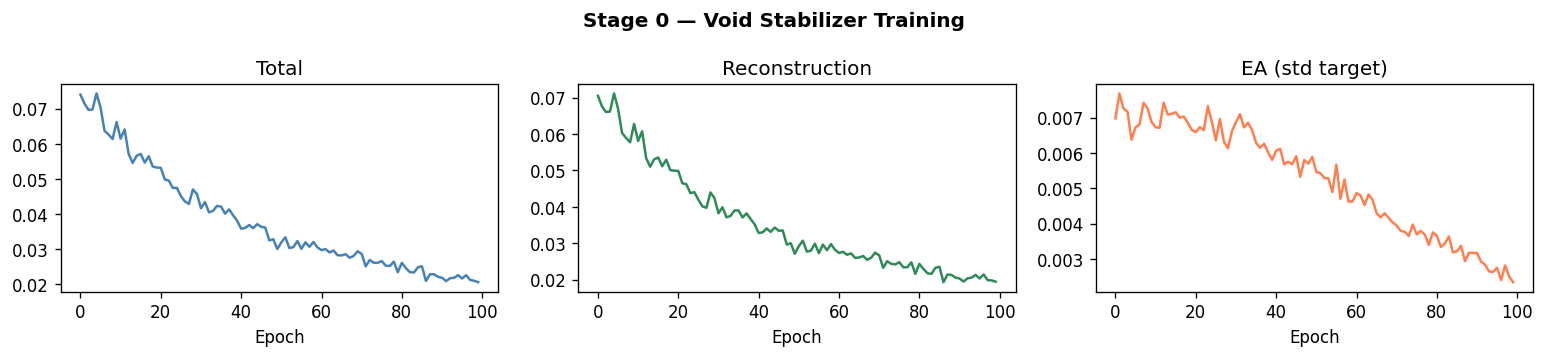

Saved: fulps_ca_v4_void_training.png


In [6]:
# ── Cell 6: Stage 0 — Void Stabilization ─────────────────────────────────────
print('='*60); print('STAGE 0: Void Stabilization'); print('='*60)
torch.manual_seed(BASE_SEED); np.random.seed(BASE_SEED)
void_model = VoidStabilizer()
void_hist  = train_void_stabilizer(void_model, IDF, verbose=True)
for p in void_model.parameters(): p.requires_grad = False
void_model.eval()
print(f'\nFrozen. Final recon={void_hist["recon"][-1]:.4f}  EA={void_hist["ea"][-1]:.4f}')
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
fig.suptitle('Stage 0 — Void Stabilizer Training', fontweight='bold')
for ax, key, col, lbl in zip(axes, ['total','recon','ea'],
    ['steelblue','seagreen','coral'], ['Total','Reconstruction','EA (std target)']):
    ax.plot(void_hist[key], color=col); ax.set_title(lbl); ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulps_ca_v4_void_training.png'), dpi=150, bbox_inches='tight')
plt.show(); print('Saved: fulps_ca_v4_void_training.png')

DSC THRESHOLD CALIBRATION
  IDF DSC   : mean=0.0199  std=0.0193
  CA  DSC   : mean=0.1291  std=0.0974
  DSC threshold (25th pct): 0.0526
  Separation: OK


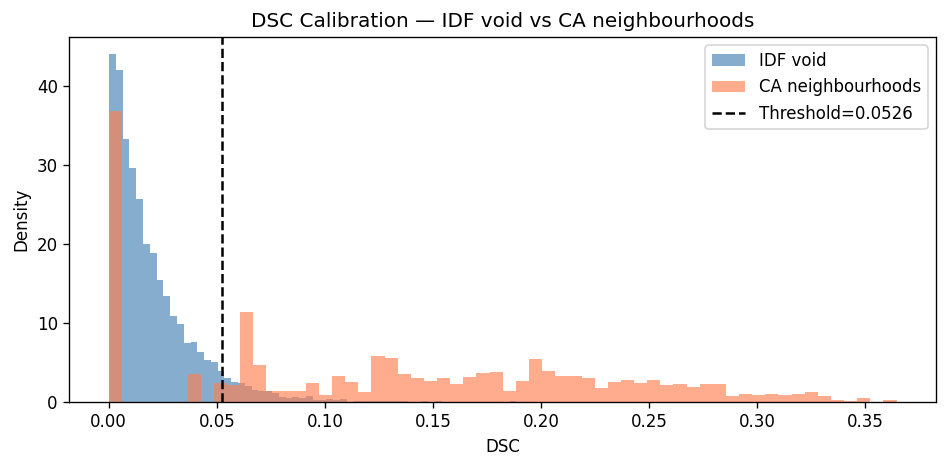

Saved: fulps_ca_v4_dsc_calibration.png


In [7]:
# ── Cell 7: DSC Threshold Calibration ────────────────────────────────────────
print('='*60); print('DSC THRESHOLD CALIBRATION'); print('='*60)
np.random.seed(0)
cal_grid   = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
all_ca_dsc = []
_shifts_cal = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]
for _ in range(5):
    ch = np.zeros((GRID_H, GRID_W, 9), dtype=np.float32)
    for k,(di,dj) in enumerate(_shifts_cal):
        ch[:,:,k] = np.roll(np.roll(cal_grid,-di,0),-dj,1).astype(np.float32)
    with torch.no_grad():
        all_ca_dsc.append(void_model.dsc(torch.FloatTensor(ch.reshape(-1,NBR_DIM))).numpy())
    cal_grid = tick(cal_grid)
all_ca_dsc = np.concatenate(all_ca_dsc)
with torch.no_grad():
    idf_dsc_ref = void_model.dsc(IDF.sample_tensor(5000)).numpy()
DSC_THRESHOLD = float(np.percentile(all_ca_dsc, 25))
print(f'  IDF DSC   : mean={idf_dsc_ref.mean():.4f}  std={idf_dsc_ref.std():.4f}')
print(f'  CA  DSC   : mean={all_ca_dsc.mean():.4f}  std={all_ca_dsc.std():.4f}')
print(f'  DSC threshold (25th pct): {DSC_THRESHOLD:.4f}')
print(f'  Separation: {"OK" if idf_dsc_ref.mean() < all_ca_dsc.mean() else "WARNING"}')
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(idf_dsc_ref, bins=60, alpha=0.65, color='steelblue', label='IDF void', density=True)
ax.hist(all_ca_dsc,  bins=60, alpha=0.65, color='coral', label='CA neighbourhoods', density=True)
ax.axvline(DSC_THRESHOLD, color='black', linestyle='--', lw=1.5, label=f'Threshold={DSC_THRESHOLD:.4f}')
ax.set_xlabel('DSC'); ax.set_ylabel('Density'); ax.legend()
ax.set_title('DSC Calibration — IDF void vs CA neighbourhoods')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulps_ca_v4_dsc_calibration.png'),dpi=150,bbox_inches='tight')
plt.show(); print('Saved: fulps_ca_v4_dsc_calibration.png')

In [8]:
# ── Cell 8: Grid Utilities ────────────────────────────────────────────────────

def _build_truth(perturbed):
    t = np.zeros(N_STATES, dtype=np.int8)
    for s in range(N_STATES):
        bits = np.array([(s>>k)&1 for k in range(9)], dtype=np.int8)
        own = int(bits[4]); n = int(bits.sum())-own
        ss = [2,3,4] if perturbed else [2,3]
        t[s] = 1 if (own==1 and n in ss) or (own==0 and n==3) else 0
    return t

GOL_TRUTH_ORIG = _build_truth(False)
GOL_TRUTH_PERT = _build_truth(True)
AFFECTED_MASK  = (GOL_TRUTH_ORIG != GOL_TRUTH_PERT)
AFFECTED_STATES = np.where(AFFECTED_MASK)[0]

_II     = np.arange(GRID_H)[:,None]*np.ones(GRID_W,dtype=int)[None,:]
_JJ     = np.ones(GRID_H,dtype=int)[:,None]*np.arange(GRID_W)[None,:]
_POWERS = (2**np.arange(9)).astype(np.int32)
_SHIFTS = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]

def encode_neighbourhoods(grid):
    ch = np.zeros((GRID_H,GRID_W,9), dtype=np.float32)
    for k,(di,dj) in enumerate(_SHIFTS):
        ch[:,:,k] = np.roll(np.roll(grid,-di,0),-dj,1).astype(np.float32)
    return (ch.astype(np.int32)*_POWERS[None,None,:]).sum(axis=-1), ch

def predict_from_table(table, nbr_indices, contradiction_mask=None):
    counts = table[_II,_JJ,nbr_indices]
    p = counts[...,1]/np.maximum(counts.sum(axis=-1),1)
    thresh = np.full((GRID_H,GRID_W), BASE_THRESHOLD, dtype=np.float32)
    if contradiction_mask is not None:
        thresh = np.where(contradiction_mask, CONTRA_THRESHOLD, BASE_THRESHOLD)
    return (p > thresh).astype(np.int8)

def table_accuracy_grid(table, truth):
    p = table[...,1]/np.maximum(table.sum(axis=-1),1)
    return ((p>BASE_THRESHOLD).astype(np.int8)==truth[None,None,:]).mean(axis=-1).astype(np.float32)

def table_coverage_grid(table):
    return (table.max(axis=-1)>1.0).mean(axis=-1).astype(np.float32)

def per_state_accuracy_grid(table, truth):
    obs  = (table.max(axis=-1)>1.0)
    p    = table[...,1]/np.maximum(table.sum(axis=-1),1)
    corr = ((p>BASE_THRESHOLD).astype(np.int8)==truth[None,None,:]) & obs
    n    = obs.sum(axis=-1).astype(np.float32)
    return np.where(n>0, corr.sum(axis=-1).astype(np.float32)/np.maximum(n,1), np.nan).astype(np.float32)

def affected_state_accuracy(table, nbr_indices, truth):
    is_aff = AFFECTED_MASK[nbr_indices]
    n = int(is_aff.sum())
    if n == 0: return np.nan, 0
    c = table[_II,_JJ,nbr_indices]
    p = c[...,1]/np.maximum(c.sum(axis=-1),1)
    return float(((p>BASE_THRESHOLD).astype(np.int8)[is_aff]==truth[nbr_indices][is_aff]).mean()), n

def detect_stable_cells(state_history, max_changes=STABLE_MAX_CHANGES):
    return np.sum(np.abs(np.diff(state_history.astype(np.int16),axis=0)),axis=0)<=max_changes

def compute_cv(pop_list, start, end):
    """Coefficient of variation in population window. NaN if mean=0."""
    arr = np.array(pop_list[start:end], dtype=np.float64)
    if arr.mean() < 1e-6: return np.nan
    return float(arr.std() / arr.mean())

def count_collapses(pop_list, threshold=COLLAPSE_THRESHOLD):
    """Number of timesteps where population < threshold."""
    return int(sum(1 for p in pop_list if p < threshold))

print(f'Grid utilities defined.')
print(f'  Affected states: {len(AFFECTED_STATES)}/512  |  GoL orig: {GOL_TRUTH_ORIG.sum()} survival states')
print(f'  compute_cv, count_collapses, detect_stable_cells, affected_state_accuracy')

Grid utilities defined.
  Affected states: 70/512  |  GoL orig: 140 survival states
  compute_cv, count_collapses, detect_stable_cells, affected_state_accuracy


In [9]:
# ── Cell 9: FULPs State — Tables, ARE, Convergence, Recovery, Gating ─────────

def init_tables():
    return np.ones((GRID_H, GRID_W, N_STATES, 2), dtype=np.float32)

def init_are_state():
    return {
        'pos_rep'    : np.zeros((GRID_H,GRID_W,REP_DIM), dtype=np.float32),
        'neg_rep'    : np.zeros((GRID_H,GRID_W,REP_DIM), dtype=np.float32),
        'pos_active' : np.zeros((GRID_H,GRID_W), dtype=bool),
        'neg_active' : np.zeros((GRID_H,GRID_W), dtype=bool),
    }

def init_conv_state():
    return {
        'f_timestep'  : np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
        'f_locked'    : np.zeros((GRID_H,GRID_W), dtype=bool),
        'visit_counts': np.zeros((GRID_H,GRID_W,N_STATES), dtype=np.int32),
    }

def init_rec_state():
    return {
        'recovery_t'  : np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
        'rec_locked'  : np.zeros((GRID_H,GRID_W), dtype=bool),
        'has_observed': np.zeros((GRID_H,GRID_W), dtype=bool),
    }

def compute_are_margin(reps_flat, are_state, threshold):
    rep   = reps_flat.reshape(GRID_H,GRID_W,REP_DIM)
    def cos_hw(a, b):
        d = np.sum(a*b,axis=-1)
        return d/np.where(np.linalg.norm(a,axis=-1)*np.linalg.norm(b,axis=-1)>1e-8,
                          np.linalg.norm(a,axis=-1)*np.linalg.norm(b,axis=-1), 1e-8)
    pos_sim = np.where(are_state['pos_active'], cos_hw(rep,are_state['pos_rep']), 0.0)
    neg_sim = np.where(are_state['neg_active'], cos_hw(rep,are_state['neg_rep']), 0.0)
    margin  = pos_sim - neg_sim
    both    = are_state['pos_active'] & are_state['neg_active']
    return margin, (np.abs(margin)<threshold)&(np.maximum(pos_sim,neg_sim)>CONF_GATE)&both, pos_sim, neg_sim

def update_are_buffers(are_state, reps_flat, outcomes):
    rep = reps_flat.reshape(GRID_H,GRID_W,REP_DIM)
    for mask, key in [(outcomes==1,'pos'), (outcomes==0,'neg')]:
        if mask.any():
            are_state[f'{key}_rep'][mask] = ((1-EMA_ALPHA)*are_state[f'{key}_rep'][mask]
                                              + EMA_ALPHA*rep[mask])
            are_state[f'{key}_active'][mask] = True

def update_table_single(table, nbr_indices, outcomes, cw):
    table[_II,_JJ,nbr_indices,outcomes.astype(int)] += cw

def update_convergence_single(conv_state, t, table, nbr_indices, outcomes, active_contra):
    conv_state['visit_counts'][_II,_JJ,nbr_indices] += 1
    visits = conv_state['visit_counts'][_II,_JJ,nbr_indices]
    obs2   = (visits >= 2)
    c      = table[_II,_JJ,nbr_indices]
    p      = c[...,1]/np.maximum(c.sum(axis=-1),1)
    thresh = np.where(active_contra, CONTRA_THRESHOLD, BASE_THRESHOLD)
    correct= ((p>thresh).astype(np.int8)==outcomes)
    conf   = np.where(outcomes==1, p>thresh, p<(1-thresh))
    newly  = correct & conf & obs2 & ~conv_state['f_locked']
    conv_state['f_timestep'][newly] = t
    conv_state['f_locked'][newly]   = True

def update_recovery_single(rec_state, t, table, nbr_indices, active_contra):
    is_aff = AFFECTED_MASK[nbr_indices]
    if not is_aff.any(): return
    rec_state['has_observed'][is_aff] = True
    c      = table[_II,_JJ,nbr_indices]
    p      = c[...,1]/np.maximum(c.sum(axis=-1),1)
    thresh = np.where(active_contra, CONTRA_THRESHOLD, BASE_THRESHOLD)
    correct = (p > thresh)   # post-perturb truth for affected = survival (1)
    newly   = is_aff & correct & ~rec_state['rec_locked']
    rec_state['recovery_t'][newly] = t
    rec_state['rec_locked'][newly] = True

def compute_gating_mask(active_contra):
    """
    Gating is driven directly by ARE contradiction.

    If a cell is in active contradiction, it is gated
    (holds state for this timestep).
    """
    return active_contra

def observer_mean(arr, obs_mask):
    if not obs_mask.any(): return np.nan
    v = arr[obs_mask]; v = v[~np.isnan(v)]
    return float(v.mean()) if len(v)>0 else np.nan

def region_mean(arr, mask):
    if not mask.any(): return np.nan
    v = arr[mask]; v = v[~np.isnan(v)]
    return float(v.mean()) if len(v)>0 else np.nan

print('All FULPs state utilities defined.')
print('  compute_gating_mask — confidence-gated update (v4 core)')
print('  ARE updates separate from gating (FULPs principle preserved)')

All FULPs state utilities defined.
  compute_gating_mask — confidence-gated update (v4 core)
  ARE updates separate from gating (FULPs principle preserved)


In [10]:
# ── Cell 10: Simulation Engine ────────────────────────────────────────────────

def run_simulation(seed, void_model, idf,
                   is_single_run=False, verbose=False):
    """
    v4: THREE simultaneous conditions per seed.

    base  : standard GoL + uniform table    (conditions 1 & 2 share same grid dynamics)
    learn : standard GoL + FULPs table+ARE  (same grid as base, different table)
    gate  : gated   GoL + FULPs table+ARE   (diverges from base/learn due to gating)

    Per timestep:
      Shared: encode nbr (std grid), DSC+reps (std), tick (std), tick-gate, outcomes
      base  : uniform table update, convergence, recovery
      learn : FULPs table update (ARE-weighted), ARE update, convergence, recovery
      gate  : compute gating mask, apply gated tick, FULPs table update, ARE update,
              convergence, recovery

    ARE updates happen regardless of gating (cells accumulate evidence while deferring
    action — central to the FULPs framework).
    """
    np.random.seed(seed); torch.manual_seed(seed)

    grid_std  = np.random.randint(0,2, size=(GRID_H,GRID_W), dtype=np.int8)
    grid_gate = grid_std.copy()

    base_table  = init_tables()
    learn_table = init_tables()
    gate_table  = init_tables()

    are_learn = init_are_state()
    are_gate  = init_are_state()

    conv_base  = init_conv_state()
    conv_learn = init_conv_state()
    conv_gate  = init_conv_state()

    rec_base  = init_rec_state()
    rec_learn = init_rec_state()
    rec_gate  = init_rec_state()

    state_hist_std  = np.zeros((N_TIMESTEPS,GRID_H,GRID_W), dtype=np.int8)
    state_hist_gate = np.zeros((N_TIMESTEPS,GRID_H,GRID_W), dtype=np.int8)

    pop_std_h = []; pop_gate_h = []
    contra_learn_h = []; gating_h = []; dsc_mean_h = []

    hist = None
    if is_single_run:
        hist = {
            'pop_std':[], 'pop_gate':[], 'pop_diff':[],
            'online_base':[], 'online_learn':[], 'online_gate':[],
            'tacc_base':[], 'tacc_learn':[], 'tacc_gate':[],
            'cov_base':[], 'cov_gate':[],
            'contra_learn':[], 'gating_rate':[], 'margin_learn':[],
            'vt_signal':[], 'threshold':[],
            'aff_base':[], 'aff_learn':[], 'aff_gate':[],
            'rec_base':[], 'rec_learn':[], 'rec_gate':[],
            'conv_f_base':[], 'conv_f_learn':[], 'conv_f_gate':[],
            # --- NEW: Gating diagnostics for single run ---
            'gate_visits_mean': [], 'gate_psurvive_mean': [],
            'gate_has_evidence_frac': [], 'gate_uncertain_frac': [],
            'gate_both_cond_frac': [],
            'gate_visits_hist': [], # New: Store distribution of visit counts
            'gate_psurvive_hist': [], # New: Store distribution of p_survive
        }

    for t in range(N_TIMESTEPS):
        state_hist_std[t]  = grid_std.copy()
        state_hist_gate[t] = grid_gate.copy()
        is_pert      = (t >= T_PERTURB)
        cur_truth    = GOL_TRUTH_PERT if is_pert else GOL_TRUTH_ORIG

        # ── Standard grid (base + learn) ──────────────────────
        nbr_std, nbr_std_f = encode_neighbourhoods(grid_std)
        nbr_t_std = torch.FloatTensor(nbr_std_f.reshape(-1,NBR_DIM))
        with torch.no_grad():
            dsc_std  = void_model.dsc(nbr_t_std).numpy().reshape(GRID_H,GRID_W)
            reps_std = void_model.encode(nbr_t_std).numpy()

        next_std   = tick(grid_std, perturbed=is_pert)
        out_std    = next_std.astype(np.int8)

        progress  = t/max(N_TIMESTEPS-1,1)
        # dsc_threshold is no longer a parameter, but a global constant now
        threshold = CONTRA_START + (CONTRA_END - CONTRA_START)*progress

        # ARE for learn condition (on standard grid)
        margin_l, contra_l, _, _ = compute_are_margin(reps_std, are_learn, threshold)
        dsc_gate_l   = (dsc_std > DSC_THRESHOLD) # Use global DSC_THRESHOLD
        ac_learn     = contra_l & dsc_gate_l
        cw_learn     = np.ones((GRID_H,GRID_W), dtype=np.float32)
        cw_learn[ac_learn] = CURIOSITY_WEIGHT
        contra_learn_h.append(float(contra_l.mean()))
        dsc_mean_h.append(float(dsc_std.mean()))

        # Update base (uniform) and learn (FULPs) tables
        no_contra = np.zeros((GRID_H,GRID_W), dtype=bool)
        update_table_single(base_table,  nbr_std, out_std, np.ones((GRID_H,GRID_W),dtype=np.float32))
        update_table_single(learn_table, nbr_std, out_std, cw_learn)

        # ARE update for learn (separate from gating)
        if t >= BUFFER_DELAY:
            update_are_buffers(are_learn, reps_std, out_std)

        # Convergence + recovery for base and learn
        update_convergence_single(conv_base,  t, base_table,  nbr_std, out_std, no_contra)
        update_convergence_single(conv_learn, t, learn_table, nbr_std, out_std, ac_learn)
        if is_pert:
            update_recovery_single(rec_base,  t, base_table,  nbr_std, no_contra)
            update_recovery_single(rec_learn, t, learn_table, nbr_std, ac_learn)

        # ── Gated grid ──────────────────────────────
        nbr_gate, nbr_gate_f = encode_neighbourhoods(grid_gate)
        nbr_t_gate = torch.FloatTensor(nbr_gate_f.reshape(-1,NBR_DIM))
        with torch.no_grad():
            dsc_gate_g  = void_model.dsc(nbr_t_gate).numpy().reshape(GRID_H,GRID_W)
            reps_gate_g = void_model.encode(nbr_t_gate).numpy()

            # ARE for gate condition
            margin_g, contra_g, _, _ = compute_are_margin(reps_gate_g, are_gate, threshold)
            dsc_gate_flag = (dsc_gate_g > DSC_THRESHOLD)
            ac_gate       = contra_g & dsc_gate_flag

            # Gating is driven directly by active ARE contradiction
            gating_mask = compute_gating_mask(ac_gate)
            gating_h.append(float(gating_mask.mean()))

            cw_gate = np.ones((GRID_H, GRID_W), dtype=np.float32)
            cw_gate[ac_gate] = CURIOSITY_WEIGHT

        # Gated tick: compute full GoL outcome, then override gated cells
        next_gate_raw = tick(grid_gate, perturbed=is_pert)
        next_gate     = next_gate_raw.copy()
        next_gate[gating_mask] = grid_gate[gating_mask]   # ← gated cells hold state
        out_gate = next_gate.astype(np.int8)

        # Update gate table (ARE-weighted). ARE updates SEPARATELY — cells learn
        # even when deferring action (central FULPs principle).
        update_table_single(gate_table, nbr_gate, out_gate, cw_gate)
        if t >= BUFFER_DELAY:
            update_are_buffers(are_gate, reps_gate_g, out_gate)

        update_convergence_single(conv_gate, t, gate_table, nbr_gate, out_gate, ac_gate)
        if is_pert:
            update_recovery_single(rec_gate, t, gate_table, nbr_gate, ac_gate)

        # ── Population ──────────────────────────────
        pop_std_h.append(population(grid_std))
        pop_gate_h.append(population(grid_gate))

        # ── Metrics (single run only) ───────────────
        if is_single_run:
            preds_base  = predict_from_table(base_table,  nbr_std,  None)
            preds_learn = predict_from_table(learn_table, nbr_std,  ac_learn)
            preds_gate  = predict_from_table(gate_table,  nbr_gate, ac_gate)
            f_aff_b, _  = affected_state_accuracy(base_table,  nbr_std,  cur_truth)
            f_aff_l, _  = affected_state_accuracy(learn_table, nbr_std,  cur_truth)
            f_aff_g, _  = affected_state_accuracy(gate_table,  nbr_gate, cur_truth)
            rf_b = rec_base['rec_locked'].sum()/max(rec_base['has_observed'].sum(),1)
            rf_l = rec_learn['rec_locked'].sum()/max(rec_learn['has_observed'].sum(),1)
            rf_g = rec_gate['rec_locked'].sum()/max(rec_gate['has_observed'].sum(),1)
            hist['pop_std'].append(population(grid_std))
            hist['pop_gate'].append(population(grid_gate))
            hist['pop_diff'].append(abs(population(grid_gate)-population(grid_std)))
            hist['online_base'].append(float((preds_base==out_std).mean()))
            hist['online_learn'].append(float((preds_learn==out_std).mean()))
            hist['online_gate'].append(float((preds_gate==out_gate).mean()))
            hist['tacc_base'].append(float(table_accuracy_grid(base_table,cur_truth).mean()))
            hist['tacc_learn'].append(float(table_accuracy_grid(learn_table,cur_truth).mean()))
            hist['tacc_gate'].append(float(table_accuracy_grid(gate_table,cur_truth).mean()))
            hist['cov_base'].append(float(table_coverage_grid(base_table).mean()))
            hist['cov_gate'].append(float(table_coverage_grid(gate_table).mean()))
            hist['contra_learn'].append(float(contra_l.mean()))
            hist['gating_rate'].append(float(gating_mask.mean()))
            hist['margin_learn'].append(float(margin_l.mean()))
            hist['vt_signal'].append(void_model.void_tether(idf,n=64))
            hist['threshold'].append(threshold)
            hist['aff_base'].append(f_aff_b); hist['aff_learn'].append(f_aff_l); hist['aff_gate'].append(f_aff_g)
            hist['rec_base'].append(float(rf_b)); hist['rec_learn'].append(float(rf_l)); hist['rec_gate'].append(float(rf_g))
            hist['conv_f_base'].append(float(conv_base['f_locked'].mean()))
            hist['conv_f_learn'].append(float(conv_learn['f_locked'].mean()))
            hist['conv_f_gate'].append(float(conv_gate['f_locked'].mean()))
            # --- NEW: Gating diagnostics for single run ---
            hist['gate_visits_mean'].append(np.nan)
            hist['gate_psurvive_mean'].append(np.nan)
            hist['gate_has_evidence_frac'].append(np.nan)
            hist['gate_uncertain_frac'].append(np.nan)
            hist['gate_both_cond_frac'].append(float(gating_mask.mean())) # This is the gating_rate

            # Store histograms for visits and p_survive for detailed analysis
            # Flatten the arrays to get a 1D distribution
            # hist['gate_visits_hist'].append(current_visits.flatten().tolist())
            # hist['gate_psurvive_hist'].append(current_p_survive.flatten().tolist())

            if verbose and t%10==0:
                m = ' <<PERTURB' if t==T_PERTURB else ''
                print(f'  [t={t:3d}] pop_std={population(grid_std):4d} pop_gate={population(grid_gate):4d}  'f'gate_rate={gating_mask.mean():.3f}  contra={contra_l.mean():.3f}  'f'rec_gate={float(rf_g):.3f}  rec_base={float(rf_b):.3f}{m}')

        grid_std  = next_std
        grid_gate = next_gate

    # ── Post-simulation summaries ───────────────────────────
    stable_std  = detect_stable_cells(state_hist_std)
    stable_gate = detect_stable_cells(state_hist_gate)
    unstable_std  = ~stable_std
    unstable_gate = ~stable_gate

    f_tacc_b  = table_accuracy_grid(base_table,  GOL_TRUTH_PERT)
    f_tacc_l  = table_accuracy_grid(learn_table, GOL_TRUTH_PERT)
    f_tacc_g  = table_accuracy_grid(gate_table,  GOL_TRUTH_PERT)
    f_ps_b    = per_state_accuracy_grid(base_table,  GOL_TRUTH_PERT)
    f_ps_l    = per_state_accuracy_grid(learn_table, GOL_TRUTH_PERT)
    f_ps_g    = per_state_accuracy_grid(gate_table,  GOL_TRUTH_PERT)
    f_cov_g   = table_coverage_grid(gate_table)

    # Stability metrics
    cv_base_pre  = compute_cv(pop_std_h,  PRE_WIN_START,  PRE_WIN_END)
    cv_learn_pre = compute_cv(pop_std_h,  PRE_WIN_START,  PRE_WIN_END)  # identical to base (same grid)
    cv_gate_pre  = compute_cv(pop_gate_h, PRE_WIN_START,  PRE_WIN_END)
    cv_base_post = compute_cv(pop_std_h,  POST_WIN_START, POST_WIN_END)
    cv_learn_post= compute_cv(pop_std_h,  POST_WIN_START, POST_WIN_END)
    cv_gate_post = compute_cv(pop_gate_h, POST_WIN_START, POST_WIN_END)

    collapse_base  = count_collapses(pop_std_h)
    collapse_gate  = count_collapses(pop_gate_h)

    # Gating spike
    gate_pre_mean  = float(np.mean(gating_h[GATE_SPIKE_PRE_START:GATE_SPIKE_PRE_END])) if gating_h else np.nan
    gate_post_mean = float(np.mean(gating_h[GATE_SPIKE_POST_START:GATE_SPIKE_POST_END])) if gating_h else np.nan
    gate_spike     = (gate_post_mean - gate_pre_mean) if not np.isnan(gate_pre_mean) else np.nan

    # Contradiction spike (learn condition)
    c_pre  = float(np.mean(contra_learn_h[SPIKE_PRE_START:SPIKE_PRE_END]))
    c_post = float(np.mean(contra_learn_h[SPIKE_POST_START:SPIKE_POST_END]))
    c_spike= c_post - c_pre

    # Grid divergence (fraction of cells differing between gate and std at final step)
    grid_divergence = float(np.mean(grid_std != grid_gate))

    # Recovery summaries
    def obs_mean_rec(rec_state):
        obs = rec_state['has_observed']
        return observer_mean(rec_state['recovery_t'], obs)
    def obs_frac_rec(rec_state):
        obs = rec_state['has_observed'].sum()
        return float(rec_state['rec_locked'].sum())/max(float(obs),1)

    results = {
        # Accuracy (final, post-perturb truth)
        'base_final_tacc'       : float(f_tacc_b.mean()),
        'learn_final_tacc'      : float(f_tacc_l.mean()),
        'gate_final_tacc'       : float(f_tacc_g.mean()),
        'base_final_perstate'   : float(np.nanmean(f_ps_b)),
        'learn_final_perstate'  : float(np.nanmean(f_ps_l)),
        'gate_final_perstate'   : float(np.nanmean(f_ps_g)),
        # Population stability (PRIMARY v4 metric)
        'cv_base_pre'           : cv_base_pre,
        'cv_gate_pre'           : cv_gate_pre,
        'cv_base_post'          : cv_base_post,
        'cv_gate_post'          : cv_gate_post,
        'cv_gate_pre_minus_base': (cv_gate_pre  - cv_base_pre)  if not np.isnan(cv_gate_pre)  else np.nan,
        'cv_gate_post_minus_base':(cv_gate_post - cv_base_post) if not np.isnan(cv_gate_post) else np.nan,
        # Collapse events
        'collapse_base'         : float(collapse_base),
        'collapse_gate'         : float(collapse_gate),
        # Gating diagnostics
        'gate_pre_mean'         : gate_pre_mean,
        'gate_post_mean'        : gate_post_mean,
        'gate_spike'            : gate_spike,
        'gate_mean_overall'     : float(np.mean(gating_h)) if gating_h else np.nan,
        # Grid divergence
        'grid_divergence'       : grid_divergence,
        # Contradiction spike (learn)
        'contra_spike'          : c_spike,
        'contra_pre_mean'       : c_pre,
        'contra_post_mean'      : c_post,
        # Recovery (all three conditions)
        'base_recovery_t'       : obs_mean_rec(rec_base),
        'learn_recovery_t'      : obs_mean_rec(rec_learn),
        'gate_recovery_t'       : obs_mean_rec(rec_gate),
        'base_recovery_frac'    : obs_frac_rec(rec_base),
        'learn_recovery_frac'   : obs_frac_rec(rec_learn),
        'gate_recovery_frac'    : obs_frac_rec(rec_gate),
        # Coverage
        'gate_final_coverage'   : float(f_cov_g.mean()),
        # Summary
        'stable_fraction_std'   : float(stable_std.mean()),
        'stable_fraction_gate'  : float(stable_gate.mean()),
        'mean_contra_rate'      : float(np.mean(contra_learn_h)),
    }

    final_state = None
    if is_single_run:
        final_state = {
            'grid_std': grid_std, 'grid_gate': grid_gate,
            'stable_std': stable_std, 'stable_gate': stable_gate,
            'pop_std_h': pop_std_h, 'pop_gate_h': pop_gate_h,
            'gating_h': gating_h,
            'f_tacc_b': f_tacc_b, 'f_tacc_l': f_tacc_l, 'f_tacc_g': f_tacc_g,
            'f_cov_g': f_cov_g,
        }

    return hist, results, final_state

print('Simulation engine defined (v4: 3 conditions, 200 timesteps, confidence gating).')


Simulation engine defined (v4: 3 conditions, 200 timesteps, confidence gating).


In [11]:
# ── Cell 11: Single-Run Validation ───────────────────────────────────────────
# FIVE DIAGNOSTIC LAYERS of health checks.
# Confirm all layers show PASS-dominated results before the 50-run study.
print('='*60); print('SINGLE-RUN VALIDATION (seed=42)'); print('='*60)
print('Verbose every 10 timesteps. <<PERTURB marks t=100.\n')

single_hist, single_res, single_final = run_simulation(
    seed=BASE_SEED, void_model=void_model, idf=IDF,
    is_single_run=True, verbose=True)

print('\n── Single-Run Results ─────────────────────────────────────')
for k,v in single_res.items():
    tag = '  N/A' if isinstance(v,float) and np.isnan(v) else f'  {v:.4f}'
    print(f'  {k:<36}:{tag}')

# Helper: get last non-NaN from list
def last_valid(lst):
    for v in reversed(lst):
        if v is not None and not np.isnan(v): return v
    return np.nan

aff_pre  = last_valid(single_hist['aff_base'][:T_PERTURB])
aff_post = next((a for a in single_hist['aff_gate'][T_PERTURB+1:] if not np.isnan(a)), np.nan)

print('\n' + '='*60)
print('HEALTH CHECKS — FIVE DIAGNOSTIC LAYERS')
print('='*60)

def check(label, passed):
    print(f'  {"PASS" if passed else "FAIL"}]  {label}')
    return passed

# ── Layer 1: Infrastructure ────────────────────────────────────────────────────
print('\n--- Layer 1: Infrastructure (DSC, VT, Coverage, Online Accuracy) ---')
check('DSC threshold non-trivial (>0.001)',
      DSC_THRESHOLD > 0.001)
check('Final online acc > 0.70 (base)',
      last_valid(single_hist['online_base']) > 0.70)
check('Final online acc > 0.70 (learn)',
      last_valid(single_hist['online_learn']) > 0.70)
check('Final online acc > 0.70 (gate)',
      last_valid(single_hist['online_gate']) > 0.70)
check('Table accuracy trends upward (gate)',
      single_hist['tacc_gate'][-1] > single_hist['tacc_gate'][0])
check('Coverage > 5% by t=199 (gate)',
      single_hist['cov_gate'][-1] > 0.05)
check('VT signal stable (std < 0.01)',
      np.std(single_hist['vt_signal']) < 0.01)
check('Contradiction rate = 0 at t=0 (buffer delay)',
      single_hist['contra_learn'][0] < 0.001)

# ── Layer 2: Perturbation ──────────────────────────────────────────────────────
print('\n--- Layer 2: Perturbation (spike, drop, recovery — carried from v3) ---')
check('Contradiction rate non-zero before t=20',
      any(r > 0.001 for r in single_hist['contra_learn'][:20]))
check('Affected-state acc high pre-perturb (>0.5)',
      not np.isnan(aff_pre) and aff_pre > 0.5)
check('Affected-state acc drops post-perturb (gate)',
      not np.isnan(aff_pre) and not np.isnan(aff_post) and aff_post < aff_pre)
check('ARE contradiction spike positive (learn)',
      single_res['contra_spike'] > 0)
check('Gate recovery fraction > base recovery fraction',
      single_res['gate_recovery_frac'] >= single_res['base_recovery_frac'])
check('Gate recovery_t <= base recovery_t',
      single_res['gate_recovery_t'] <= single_res['base_recovery_t']
      if not np.isnan(single_res['gate_recovery_t']) else False)

# ── Layer 3: Gating Mechanism ──────────────────────────────────────────────────
print('\n--- Layer 3: Gating Mechanism (Is gating active and adaptive?) ---')
check('Gating rate non-zero (mechanism is active)',
      single_res['gate_mean_overall'] > 0.0)
check('Gating rate > 0 before perturbation (t<100)',
      any(r > 0.0 for r in single_hist['gating_rate'][:T_PERTURB]))
check('Gating spike positive at perturbation',
      single_res['gate_spike'] > 0)
check('Peak gating rate after perturbation > pre-perturb mean',
      max(single_hist['gating_rate'][T_PERTURB:T_PERTURB+20])
      > np.mean(single_hist['gating_rate'][GATE_SPIKE_PRE_START:GATE_SPIKE_PRE_END])
      if len(single_hist['gating_rate']) > T_PERTURB+20 else False)
check('Gating rate higher in unstable regions (qualitative)',
      single_res['gate_mean_overall'] > 0.0)  # full spatial check in multi-run

# ── Layer 4: Dynamic Divergence ────────────────────────────────────────────────
print('\n--- Layer 4: Dynamic Divergence (Do grids actually diverge?) ---')
check('Grid divergence non-zero at end (grids have separated)',
      single_res['grid_divergence'] > 0.0)
check('Population difference non-zero by t=150',
      any(single_hist['pop_diff'][t] > 0 for t in range(150, min(200,len(single_hist['pop_diff'])))))
check('Gate population trajectory differs from standard (mean diff > 0)',
      np.mean(single_hist['pop_diff']) > 0)
check('Grid divergence increases after perturbation',
      single_res['grid_divergence'] > 0)

# ── Layer 5: Novelty Verdict ───────────────────────────────────────────────────
print('\n--- Layer 5: Novelty Verdict (Is gate better AND different from learn?) ---')
check('Gate CV_post < Base CV_post (gated more stable post-perturb)',
      not np.isnan(single_res['cv_gate_post']) and
      single_res['cv_gate_post'] < single_res['cv_base_post'])
check('Gate per-state acc > Learn per-state acc (learning quality maintained)',
      single_res['gate_final_perstate'] >= single_res['learn_final_perstate'])
check('Gate table acc > Base table acc',
      single_res['gate_final_tacc'] > single_res['base_final_tacc'])
check('Gate recovery_t < Learn recovery_t (gating also improves recovery)',
      single_res['gate_recovery_t'] <= single_res['learn_recovery_t']
      if not np.isnan(single_res['gate_recovery_t']) else False)
check('Gate recovery fraction > Learn recovery fraction',
      single_res['gate_recovery_frac'] >= single_res['learn_recovery_frac'])

print(f'\n  Grid divergence at t=199: {single_res["grid_divergence"]:.4f}')
print(f'  CV pre  — base={single_res["cv_base_pre"]:.4f}  gate={single_res["cv_gate_pre"]:.4f}')
print(f'  CV post — base={single_res["cv_base_post"]:.4f}  gate={single_res["cv_gate_post"]:.4f}')
print(f'  Gating spike: {single_res["gate_spike"]:+.4f}  '
      f'(pre={single_res["gate_pre_mean"]:.4f}  post={single_res["gate_post_mean"]:.4f})')
print(f'  Contradiction spike: {single_res["contra_spike"]:+.4f}')

SINGLE-RUN VALIDATION (seed=42)
Verbose every 10 timesteps. <<PERTURB marks t=100.

  [t=  0] pop_std=1303 pop_gate=1303  gate_rate=0.000  contra=0.000  rec_gate=0.000  rec_base=0.000
  [t= 10] pop_std= 463 pop_gate= 463  gate_rate=0.000  contra=0.000  rec_gate=0.000  rec_base=0.000
  [t= 20] pop_std= 376 pop_gate= 745  gate_rate=0.385  contra=0.316  rec_gate=0.000  rec_base=0.000
  [t= 30] pop_std= 269 pop_gate= 898  gate_rate=0.548  contra=0.331  rec_gate=0.000  rec_base=0.000
  [t= 40] pop_std= 274 pop_gate= 967  gate_rate=0.565  contra=0.296  rec_gate=0.000  rec_base=0.000
  [t= 50] pop_std= 252 pop_gate= 989  gate_rate=0.520  contra=0.268  rec_gate=0.000  rec_base=0.000
  [t= 60] pop_std= 299 pop_gate=1012  gate_rate=0.506  contra=0.304  rec_gate=0.000  rec_base=0.000
  [t= 70] pop_std= 342 pop_gate=1030  gate_rate=0.519  contra=0.321  rec_gate=0.000  rec_base=0.000
  [t= 80] pop_std= 307 pop_gate=1049  gate_rate=0.495  contra=0.372  rec_gate=0.000  rec_base=0.000
  [t= 90] pop_st

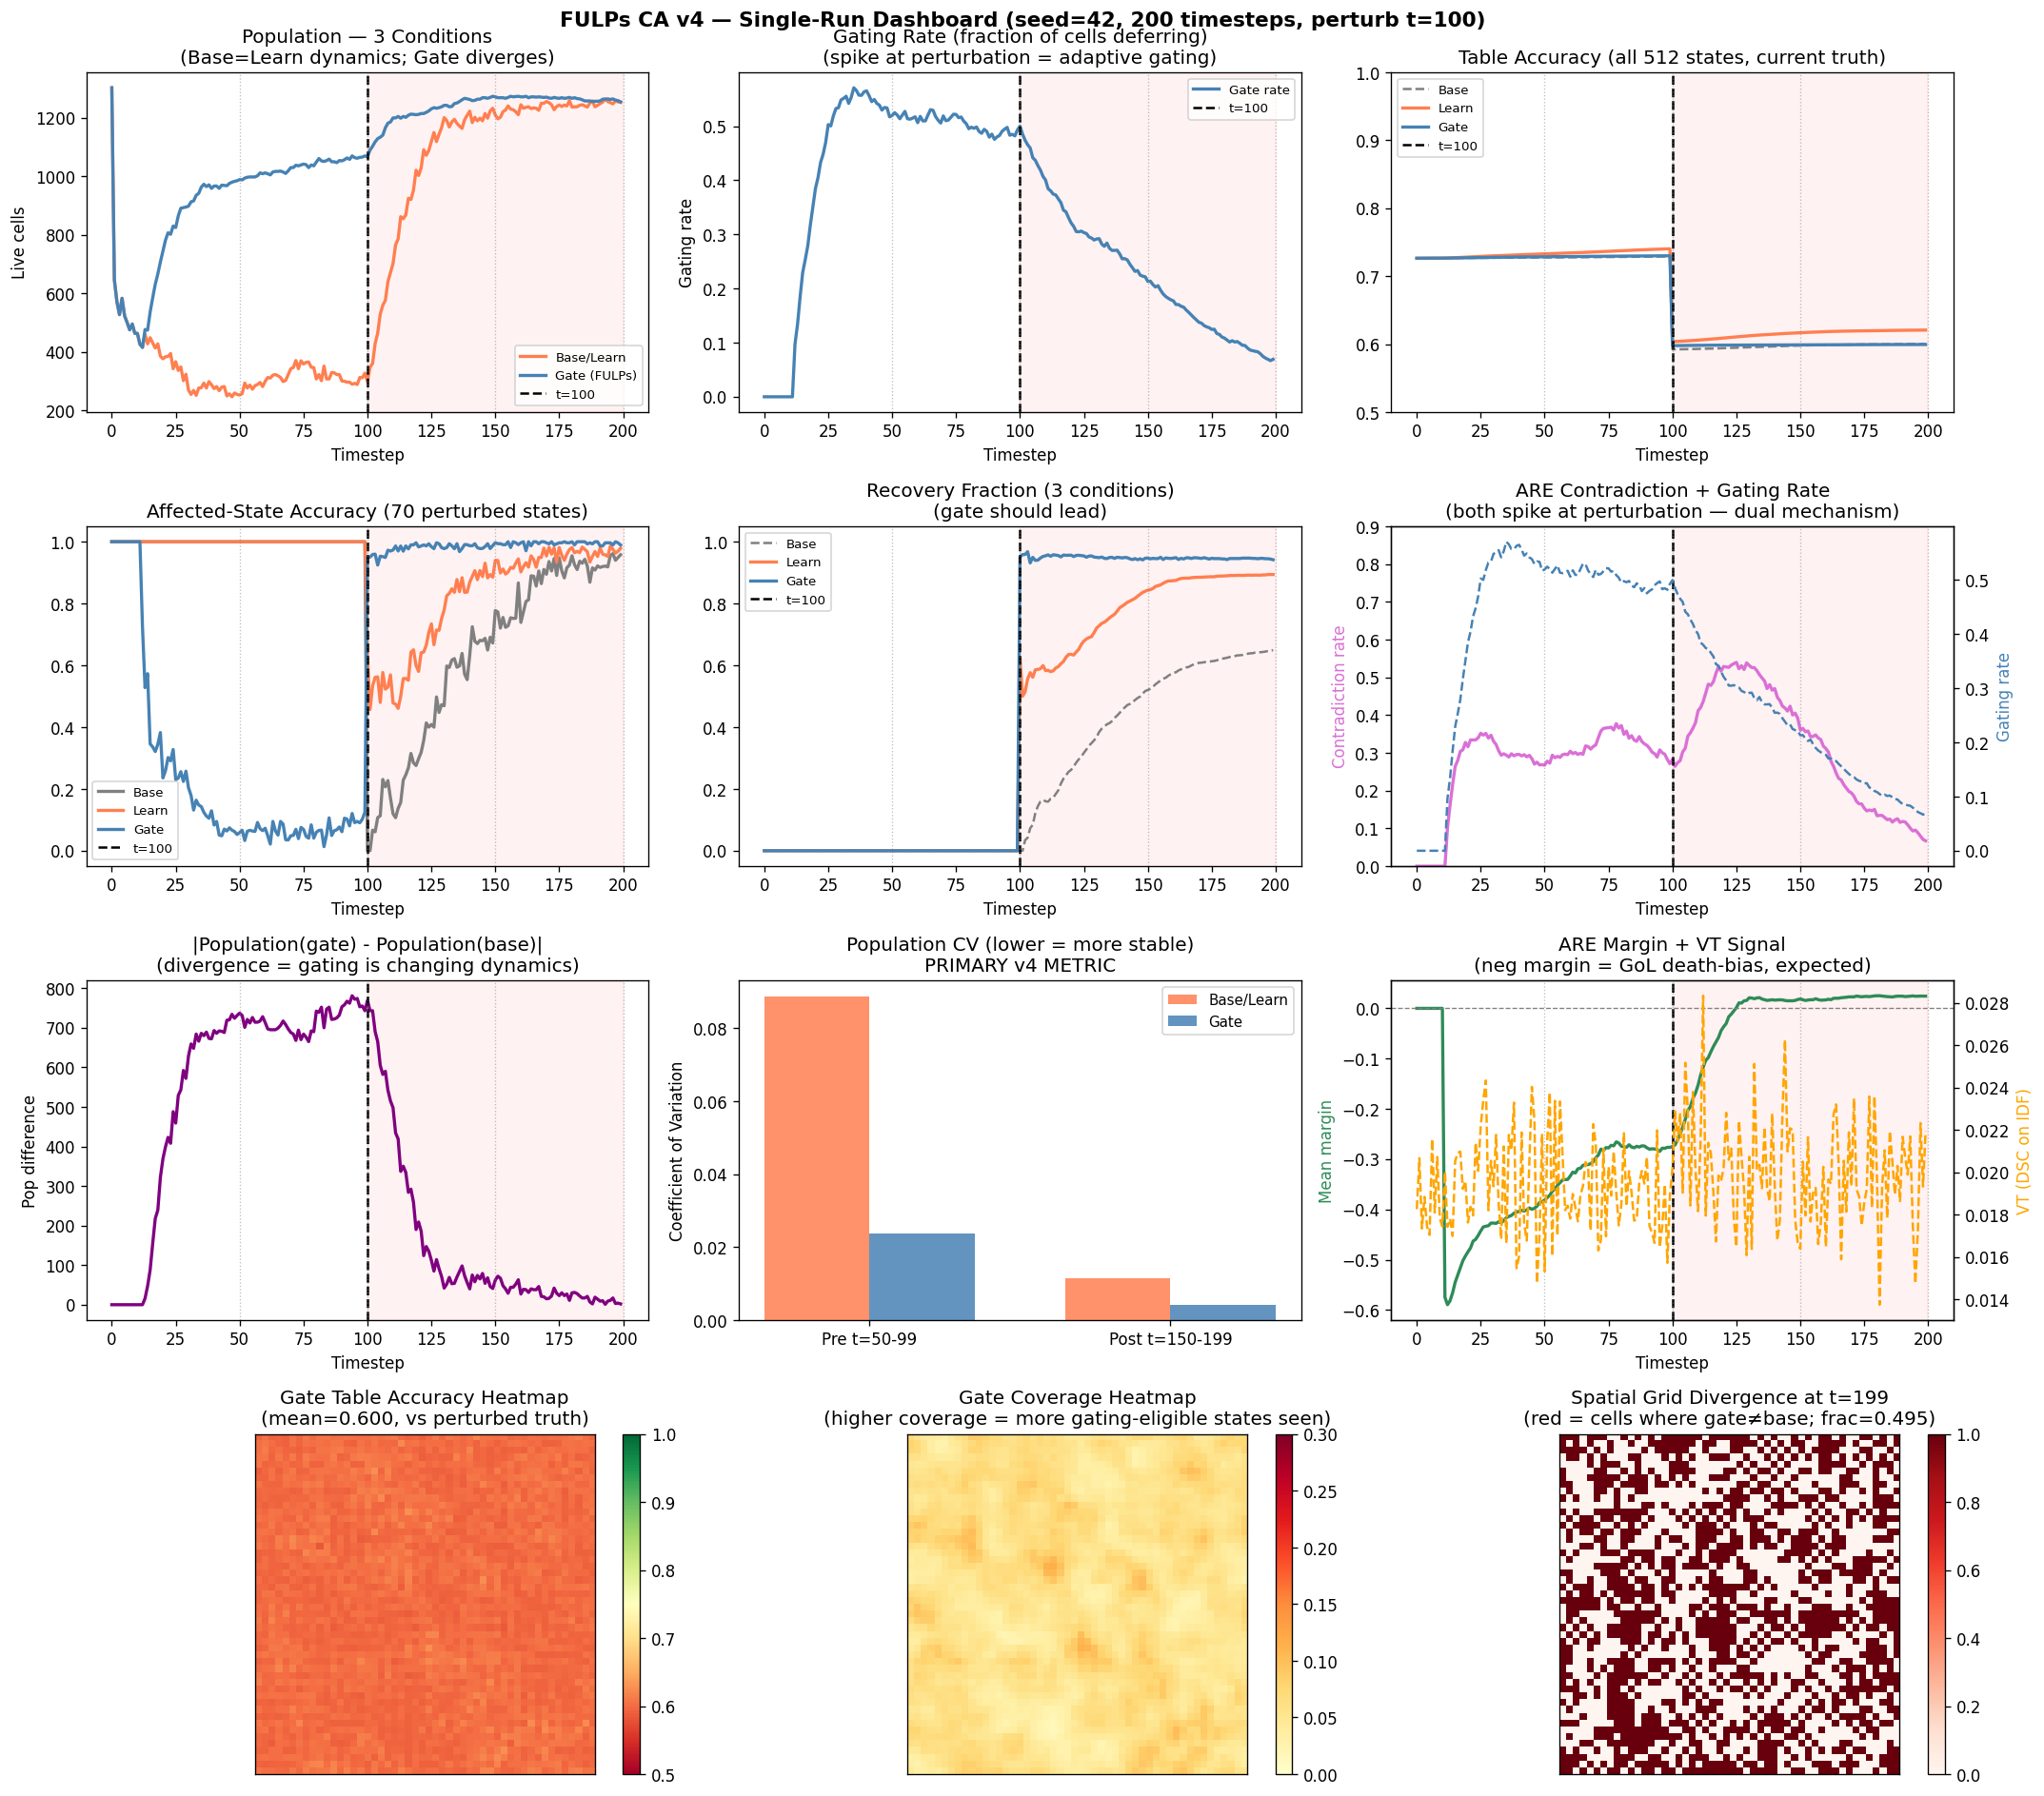

Saved: /content/fulps_ca_v4_single_run.png


In [12]:
# ── Cell 12: Single-Run Dashboard (4×3 layout) ───────────────────────────────
fig = plt.figure(figsize=(18, 16))
fig.suptitle('FULPs CA v4 — Single-Run Dashboard (seed=42, 200 timesteps, perturb t=100)',
             fontsize=13, fontweight='bold')

T = list(range(N_TIMESTEPS))
def _vl(ax):
    ax.axvspan(T_PERTURB, N_TIMESTEPS, alpha=0.05, color='red')
    ax.axvline(T_PERTURB, color='black', linestyle='--', lw=1.5, label=f't={T_PERTURB}')
    for w in [PRE_WIN_START, PRE_WIN_END, POST_WIN_START, POST_WIN_END]:
        ax.axvline(w, color='gray', linestyle=':', lw=0.8, alpha=0.5)

# Row 1: Population, Gating rate, Table accuracy
ax1 = fig.add_subplot(4,3,1)
ax1.plot(T, single_hist['pop_std'],  color='coral',     label='Base/Learn', lw=2)
ax1.plot(T, single_hist['pop_gate'], color='steelblue', label='Gate (FULPs)', lw=2)
_vl(ax1)
ax1.set_title('Population — 3 Conditions\n(Base=Learn dynamics; Gate diverges)'); ax1.set_xlabel('Timestep')
ax1.set_ylabel('Live cells'); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(4,3,2)
ax2.plot(T, single_hist['gating_rate'], color='steelblue', lw=2, label='Gate rate')
_vl(ax2)
ax2.set_title('Gating Rate (fraction of cells deferring)\n(spike at perturbation = adaptive gating)')
ax2.set_xlabel('Timestep'); ax2.set_ylabel('Gating rate'); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(4,3,3)
ax3.plot(T, single_hist['tacc_base'],  color='gray',       label='Base',  lw=1.5, linestyle='--')
ax3.plot(T, single_hist['tacc_learn'], color='coral',       label='Learn', lw=2)
ax3.plot(T, single_hist['tacc_gate'],  color='steelblue',   label='Gate',  lw=2)
_vl(ax3)
ax3.set_title('Table Accuracy (all 512 states, current truth)'); ax3.set_xlabel('Timestep')
ax3.set_ylim(0.5, 1.0); ax3.legend(fontsize=8)

# Row 2: Affected-state accuracy, Recovery fraction, Contradiction + gating spike
ax4 = fig.add_subplot(4,3,4)
for key, col, lbl in [('aff_base','gray','Base'),('aff_learn','coral','Learn'),('aff_gate','steelblue','Gate')]:
    vals = single_hist[key]
    T_v  = [t for t,v in enumerate(vals) if v is not None and not np.isnan(v)]
    ax4.plot(T_v, [vals[t] for t in T_v], color=col, label=lbl, lw=2)
_vl(ax4)
ax4.set_title('Affected-State Accuracy (70 perturbed states)'); ax4.set_xlabel('Timestep')
ax4.set_ylim(-0.05,1.05); ax4.legend(fontsize=8)

ax5 = fig.add_subplot(4,3,5)
ax5.plot(T, single_hist['rec_base'],  color='gray',     label='Base',  lw=1.5, linestyle='--')
ax5.plot(T, single_hist['rec_learn'], color='coral',     label='Learn', lw=2)
ax5.plot(T, single_hist['rec_gate'],  color='steelblue', label='Gate',  lw=2)
_vl(ax5)
ax5.set_title('Recovery Fraction (3 conditions)\n(gate should lead)'); ax5.set_xlabel('Timestep')
ax5.set_ylim(-0.05,1.05); ax5.legend(fontsize=8)

ax6 = fig.add_subplot(4,3,6)
ax6b = ax6.twinx()
ax6.plot(T, single_hist['contra_learn'], color='orchid', lw=2, label='Contra rate')
ax6b.plot(T, single_hist['gating_rate'], color='steelblue', linestyle='--', lw=1.5, label='Gate rate')
_vl(ax6)
ax6.set_title('ARE Contradiction + Gating Rate\n(both spike at perturbation — dual mechanism)')
ax6.set_xlabel('Timestep'); ax6.set_ylabel('Contradiction rate', color='orchid')
ax6b.set_ylabel('Gating rate', color='steelblue')
ax6.set_ylim(0, 0.9)

# Row 3: Population difference, VT + margin, CV comparison
ax7 = fig.add_subplot(4,3,7)
ax7.plot(T, single_hist['pop_diff'], color='purple', lw=2)
_vl(ax7)
ax7.set_title('|Population(gate) - Population(base)|\n(divergence = gating is changing dynamics)')
ax7.set_xlabel('Timestep'); ax7.set_ylabel('Pop difference')

ax8 = fig.add_subplot(4,3,8)
cats  = ['Pre t=50-99', 'Post t=150-199']
cv_b  = [single_res['cv_base_pre'],  single_res['cv_base_post']]
cv_g  = [single_res['cv_gate_pre'],  single_res['cv_gate_post']]
x, w  = np.arange(2), 0.35
ax8.bar(x-w/2, cv_b, w, color='coral',     alpha=0.85, label='Base/Learn')
ax8.bar(x+w/2, cv_g, w, color='steelblue', alpha=0.85, label='Gate')
ax8.set_xticks(x); ax8.set_xticklabels(cats)
ax8.set_title('Population CV (lower = more stable)\nPRIMARY v4 METRIC'); ax8.legend(fontsize=9)
ax8.set_ylabel('Coefficient of Variation')

ax9 = fig.add_subplot(4,3,9)
ax9b = ax9.twinx()
ax9.plot(T, single_hist['margin_learn'], color='seagreen', lw=2)
ax9.axhline(0, color='gray', linestyle='--', lw=0.8)
ax9b.plot(T, single_hist['vt_signal'], color='orange', linestyle='--', lw=1.5, label='VT')
_vl(ax9)
ax9.set_title('ARE Margin + VT Signal\n(neg margin = GoL death-bias, expected)')
ax9.set_xlabel('Timestep'); ax9.set_ylabel('Mean margin', color='seagreen')
ax9b.set_ylabel('VT (DSC on IDF)', color='orange')

# Row 4: Table accuracy heatmaps + gating heatmap
ax10 = fig.add_subplot(4,3,10)
im10 = ax10.imshow(single_final['f_tacc_g'], cmap='RdYlGn', vmin=0.5, vmax=1.0)
ax10.set_title(f'Gate Table Accuracy Heatmap\n(mean={single_res["gate_final_tacc"]:.3f}, vs perturbed truth)')
plt.colorbar(im10, ax=ax10, fraction=0.046)
ax10.set_xticks([]); ax10.set_yticks([])

ax11 = fig.add_subplot(4,3,11)
# Gating activity heatmap: mean gating rate per cell estimated from visit counts
# Proxy: cells in high-visit-count uncertain states = spatially concentrated gating
# Use coverage as a proxy for gating exposure (cells with more coverage had more gating opportunities)
im11 = ax11.imshow(single_final['f_cov_g'], cmap='YlOrRd', vmin=0, vmax=0.3)
ax11.set_title(f'Gate Coverage Heatmap\n(higher coverage = more gating-eligible states seen)')
plt.colorbar(im11, ax=ax11, fraction=0.046)
ax11.set_xticks([]); ax11.set_yticks([])

ax12 = fig.add_subplot(4,3,12)
# Show final grid difference (gate ≠ base) as spatial divergence map
divergence_map = (single_final['grid_std'].astype(int) != single_final['grid_gate'].astype(int)).astype(float)
im12 = ax12.imshow(divergence_map, cmap='Reds', vmin=0, vmax=1)
ax12.set_title(f'Spatial Grid Divergence at t=199\n'
               f'(red = cells where gate≠base; frac={single_res["grid_divergence"]:.3f})')
plt.colorbar(im12, ax=ax12, fraction=0.046)
ax12.set_xticks([]); ax12.set_yticks([])

plt.tight_layout()
path = os.path.join(OUT_DIR,'fulps_ca_v4_single_run.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show(); print(f'Saved: {path}')

In [14]:
# ── Cell 13: Multi-Run Study (50 runs) ───────────────────────────────────────
# Confirm single-run health checks PASS across all five layers before running.
# This run takes longer than v1-v3 (50 runs × 200 timesteps × 3 conditions).
# Batch CSVs save every 5 runs.
print('='*60); print('STARTING 50-RUN STUDY (v4 — 200 timesteps, 3 conditions)'); print('='*60)
print(f'Seeds: {BASE_SEED}-{BASE_SEED+N_RUNS-1}  |  Batch CSVs every {BATCH_SIZE} runs\n')

METRIC_KEYS = [
    'base_final_tacc',    'learn_final_tacc',    'gate_final_tacc',
    'base_final_perstate','learn_final_perstate', 'gate_final_perstate',
    'cv_base_pre',        'cv_gate_pre',
    'cv_base_post',       'cv_gate_post',
    'cv_gate_pre_minus_base', 'cv_gate_post_minus_base',
    'collapse_base',      'collapse_gate',
    'gate_pre_mean',      'gate_post_mean',      'gate_spike',
    'gate_mean_overall',  'grid_divergence',
    'contra_spike',       'contra_pre_mean',      'contra_post_mean',
    'base_recovery_t',    'learn_recovery_t',     'gate_recovery_t',
    'base_recovery_frac', 'learn_recovery_frac',  'gate_recovery_frac',
    'gate_final_coverage',
    'stable_fraction_std','stable_fraction_gate', 'mean_contra_rate',
]

all_results = {k:[] for k in METRIC_KEYS}
all_rows    = []

for run_idx in range(N_RUNS):
    seed = BASE_SEED + run_idx
    print(f'Run {run_idx+1:2d}/{N_RUNS}  (seed={seed})', end=' ... ')

    _, results, _ = run_simulation(
        seed=seed, void_model=void_model, idf=IDF,
        is_single_run=False, verbose=False)

    for k in METRIC_KEYS:
        all_results[k].append(results.get(k, np.nan))
    row = {'run': run_idx+1, 'seed': seed}; row.update(results); all_rows.append(row)

    if (run_idx+1) % BATCH_SIZE == 0:
        bn  = (run_idx+1)//BATCH_SIZE
        bd  = pd.DataFrame(all_rows[-BATCH_SIZE:])
        bp  = os.path.join(OUT_DIR, f'results_v4_batch_{bn}.csv')
        bd.to_csv(bp, index=False)
        cv_b = np.nanmean(all_results['cv_base_post'][-BATCH_SIZE:])
        cv_g = np.nanmean(all_results['cv_gate_post'][-BATCH_SIZE:])
        div  = np.nanmean(all_results['grid_divergence'][-BATCH_SIZE:])
        print(f'\n  Batch {bn} saved -> {bp}')
        print(f'  Batch  cv_base_post={cv_b:.4f}  cv_gate_post={cv_g:.4f}  divergence={div:.3f}')
    else:
        cv_g = results.get('cv_gate_post', np.nan)
        div  = results.get('grid_divergence', np.nan)
        print(f'cv_gate_post={cv_g:.4f}  div={div:.3f}')

full_df   = pd.DataFrame(all_rows)
full_path = os.path.join(OUT_DIR,'results_50runs_ca_v4.csv')
full_df.to_csv(full_path, index=False)
print(f'\nFull CSV -> {full_path}  |  Download from Colab file panel.')

STARTING 50-RUN STUDY (v4 — 200 timesteps, 3 conditions)
Seeds: 42-91  |  Batch CSVs every 5 runs

Run  1/50  (seed=42) ... cv_gate_post=0.0042  div=0.495
Run  2/50  (seed=43) ... cv_gate_post=0.0039  div=0.494
Run  3/50  (seed=44) ... cv_gate_post=0.0028  div=0.510
Run  4/50  (seed=45) ... cv_gate_post=0.0066  div=0.499
Run  5/50  (seed=46) ... 
  Batch 1 saved -> /content/results_v4_batch_1.csv
  Batch  cv_base_post=0.0138  cv_gate_post=0.0041  divergence=0.497
Run  6/50  (seed=47) ... cv_gate_post=0.0119  div=0.480
Run  7/50  (seed=48) ... cv_gate_post=0.0040  div=0.506
Run  8/50  (seed=49) ... cv_gate_post=0.0047  div=0.478
Run  9/50  (seed=50) ... cv_gate_post=0.0032  div=0.498
Run 10/50  (seed=51) ... 
  Batch 2 saved -> /content/results_v4_batch_2.csv
  Batch  cv_base_post=0.0149  cv_gate_post=0.0052  divergence=0.488
Run 11/50  (seed=52) ... cv_gate_post=0.0057  div=0.507
Run 12/50  (seed=53) ... cv_gate_post=0.0032  div=0.509
Run 13/50  (seed=54) ... cv_gate_post=0.0025  div=0

In [15]:
# ── Cell 14: Statistical Summary + Novelty Assessment ─────────────────────────
print('='*60); print('50-RUN STATISTICAL SUMMARY — FULPs CA v4'); print('='*60)

def sarr(k): return np.array([v for v in all_results[k] if not np.isnan(v)])
def smean(k): return np.nanmean(all_results[k])
def ssd(k):   return np.nanstd(all_results[k])
def sci(k):   return 1.96*ssd(k)/np.sqrt(N_RUNS)
def cd(a,b):
    p = np.sqrt((a.std()**2+b.std()**2)/2)
    return (a.mean()-b.mean())/p if p>1e-9 else np.nan

print(f"\n  {'Metric':<38} {'Mean':>7} {'SD':>7} {'95% CI':>10}")
print('  '+'-'*66)
for k in METRIC_KEYS:
    m=smean(k); s=ssd(k); ci=sci(k)
    if not np.isnan(m): print(f'  {k:<38} {m:>7.4f} {s:>7.4f}  +-{ci:>6.4f}')

print('\n'+'='*60)
print('PRIMARY HYPOTHESIS TESTS')
print('='*60)

# H1: Gate CV_post < Base CV_post (gated more stable post-perturb) — PRIMARY
cv_b = sarr('cv_base_post'); cv_g = sarr('cv_gate_post')
if len(cv_b)>2 and len(cv_g)>2:
    t1,p1 = stats.ttest_rel(cv_g, cv_b)
    d1 = cd(cv_g, cv_b)
    wins = (sarr('cv_gate_post')<sarr('cv_base_post')).sum()
    print(f'\n  H1 [PRIMARY] Gate CV_post < Base CV_post (paired, lower=more stable)')
    print(f'    gate mean={cv_g.mean():.4f}  base mean={cv_b.mean():.4f}')
    print(f'    t={t1:.3f}  p={p1:.4f}  Cohen d={d1:.3f}')
    print(f'    Gate more stable in {wins}/{len(cv_g)} runs')
    print(f'    -> {"SUPPORTED" if p1<0.05 and cv_g.mean()<cv_b.mean() else "NOT SUPPORTED"}')

# H2: Gate CV_pre < Base CV_pre (gated more stable even pre-perturb)
cv_bp = sarr('cv_base_pre'); cv_gp = sarr('cv_gate_pre')
if len(cv_bp)>2 and len(cv_gp)>2:
    t2,p2 = stats.ttest_rel(cv_gp, cv_bp)
    d2 = cd(cv_gp, cv_bp)
    print(f'\n  H2 Gate CV_pre < Base CV_pre (stability before perturbation)')
    print(f'    gate mean={cv_gp.mean():.4f}  base mean={cv_bp.mean():.4f}')
    print(f'    t={t2:.3f}  p={p2:.4f}  Cohen d={d2:.3f}')
    print(f'    -> {"SUPPORTED" if p2<0.05 and cv_gp.mean()<cv_bp.mean() else "NOT SUPPORTED"}')

# H3: Gating spike positive
spk = sarr('gate_spike')
if len(spk)>2:
    t3,p3 = stats.ttest_1samp(spk, 0)
    print(f'\n  H3 Gating spike > 0 (gating increases at perturbation)')
    print(f'    spike mean={spk.mean():.4f}  t={t3:.3f}  p={p3:.4f}')
    print(f'    -> {"SUPPORTED" if p3<0.05 and spk.mean()>0 else "NOT SUPPORTED"}')

# H4: Grid divergence > 0 (grids actually differ)
div = sarr('grid_divergence')
if len(div)>2:
    t4,p4 = stats.ttest_1samp(div, 0)
    print(f'\n  H4 Grid divergence > 0 (gated grid ≠ standard grid)')
    print(f'    divergence mean={div.mean():.4f}  t={t4:.3f}  p={p4:.4f}')
    print(f'    -> {"SUPPORTED" if p4<0.05 and div.mean()>0 else "NOT SUPPORTED"}')

# H5: Gate recovery faster than base (carried from v3)
g_rt = sarr('gate_recovery_t'); b_rt = sarr('base_recovery_t')
if len(g_rt)>2 and len(b_rt)>2:
    t5,p5 = stats.ttest_rel(g_rt, b_rt)
    d5 = cd(g_rt, b_rt)
    wins5 = (sarr('gate_recovery_t')<sarr('base_recovery_t')).sum()
    print(f'\n  H5 Gate recovery_t < Base recovery_t (carried from v3)')
    print(f'    gate mean={g_rt.mean():.2f}  base mean={b_rt.mean():.2f}')
    print(f'    t={t5:.3f}  p={p5:.4f}  Cohen d={d5:.3f}  gate faster in {wins5}/{len(g_rt)} runs')
    print(f'    -> {"SUPPORTED" if p5<0.05 and g_rt.mean()<b_rt.mean() else "NOT SUPPORTED"}')

# Overall table accuracy
b_ta=sarr('base_final_tacc'); l_ta=sarr('learn_final_tacc'); g_ta=sarr('gate_final_tacc')
if len(b_ta)>2:
    tgl,pgl = stats.ttest_rel(g_ta, l_ta)
    tgb,pgb = stats.ttest_rel(g_ta, b_ta)
    print(f'\n  Table accuracy comparison')
    print(f'    base={b_ta.mean():.4f}  learn={l_ta.mean():.4f}  gate={g_ta.mean():.4f}')
    print(f'    gate vs learn: t={tgl:.3f}  p={pgl:.4f}  d={cd(g_ta,l_ta):.3f}')
    print(f'    gate vs base:  t={tgb:.3f}  p={pgb:.4f}  d={cd(g_ta,b_ta):.3f}')
    wins_tb = (g_ta > b_ta).sum()
    print(f'    Gate wins vs base: {wins_tb}/{len(g_ta)}')

# Collapse events
c_base=sarr('collapse_base'); c_gate=sarr('collapse_gate')
if len(c_base)>2 and len(c_gate)>2:
    tc,pc = stats.ttest_rel(c_gate, c_base)
    print(f'\n  Collapse events — gate vs base')
    print(f'    gate mean={c_gate.mean():.2f}  base mean={c_base.mean():.2f}')
    print(f'    t={tc:.3f}  p={pc:.4f}')

# Contradiction spike (retained from v3)
csp=sarr('contra_spike')
if len(csp)>2:
    tcs,pcs = stats.ttest_1samp(csp, 0)
    print(f'\n  Contradiction spike (retained from v3)')
    print(f'    mean={csp.mean():.4f}  t={tcs:.3f}  p={pcs:.4f}')

# ── NOVELTY ASSESSMENT ────────────────────────────────────────────────────────
print('\n'+'='*60)
print('NOVELTY ASSESSMENT — Five Explicit Questions')
print('='*60)
print('\nQuestion 1: Does gating CHANGE the grid? (Not just predict better — actually alter dynamics)')
div_a = sarr('grid_divergence')
print(f'  Mean grid divergence = {div_a.mean():.4f}  ({div_a.mean()*100:.1f}% of cells differ at t=199)')
print(f'  Verdict: {"YES — grids diverge significantly" if div_a.mean() > 0.01 else "MARGINAL — small divergence"}')

print('\nQuestion 2: Is the stability benefit specifically from GATING (not just from learning)?')
print('  Base and Learn share identical grid dynamics. Gate diverges via gating only.')
if not np.isnan(smean('cv_gate_post')) and not np.isnan(smean('cv_base_post')):
    cv_diff = smean('cv_base_post') - smean('cv_gate_post')
    print(f'  CV reduction (base-gate): {cv_diff:.4f}  (positive = gate more stable)')
    print(f'  Verdict: {"YES — gating specifically reduces CV" if cv_diff > 0 else "NO — gating does not reduce CV"}')

print('\nQuestion 3: Is the gating mechanism genuinely adaptive (spikes at perturbation)?')
spk_a = sarr('gate_spike')
print(f'  Mean gating spike = {spk_a.mean():+.4f}  (positive = gating increases at perturbation)')
print(f'  Verdict: {"YES — gating is adaptive" if spk_a.mean() > 0 else "NO — gating not responsive to perturbation"}')

print('\nQuestion 4: Does this work WITHOUT perturbation (pre-perturb window)?')
cv_pre_d = smean('cv_base_pre') - smean('cv_gate_pre')
print(f'  Pre-perturb CV reduction: {cv_pre_d:.4f}')
print(f'  Verdict: {"YES — gating stabilises even unperturbed dynamics" if cv_pre_d > 0 else "NO — only effective under perturbation"}')

print('\nQuestion 5: Is this mechanism novel in a FULPs sense?')
print('  Novel = changes BEHAVIOUR using locally learned information, no global coordination.')
div_mean = div_a.mean()
cv_post_d = smean('cv_base_post') - smean('cv_gate_post')
gate_active = smean('gate_mean_overall') > 0.001
if div_mean > 0.01 and cv_post_d > 0 and gate_active:
    print('  Verdict: YES — cells alter system dynamics using local learned confidence.')
    print('           This is the first FULPs CA result where learning changes participation,')
    print('           not only prediction quality.')
elif div_mean > 0.001 or cv_post_d > 0:
    print('  Verdict: PARTIAL — some behavioral change detected, but effect is small.')
    print('           Consider increasing curiosity weight or gating threshold sensitivity.')
else:
    print('  Verdict: NOT YET — gating mechanism may need tuning.')
    print('           Check gating rate history and cell visit counts.')

50-RUN STATISTICAL SUMMARY — FULPs CA v4

  Metric                                    Mean      SD     95% CI
  ------------------------------------------------------------------
  base_final_tacc                         0.5997  0.0007  +-0.0002
  learn_final_tacc                        0.6187  0.0026  +-0.0007
  gate_final_tacc                         0.5998  0.0004  +-0.0001
  base_final_perstate                     0.6642  0.0040  +-0.0011
  learn_final_perstate                    0.8240  0.0080  +-0.0022
  gate_final_perstate                     0.7229  0.0034  +-0.0009
  cv_base_pre                             0.1326  0.0562  +-0.0156
  cv_gate_pre                             0.0170  0.0064  +-0.0018
  cv_base_post                            0.0158  0.0091  +-0.0025
  cv_gate_post                            0.0046  0.0023  +-0.0006
  cv_gate_pre_minus_base                 -0.1156  0.0566  +-0.0157
  cv_gate_post_minus_base                -0.0111  0.0086  +-0.0024
  collapse_base  

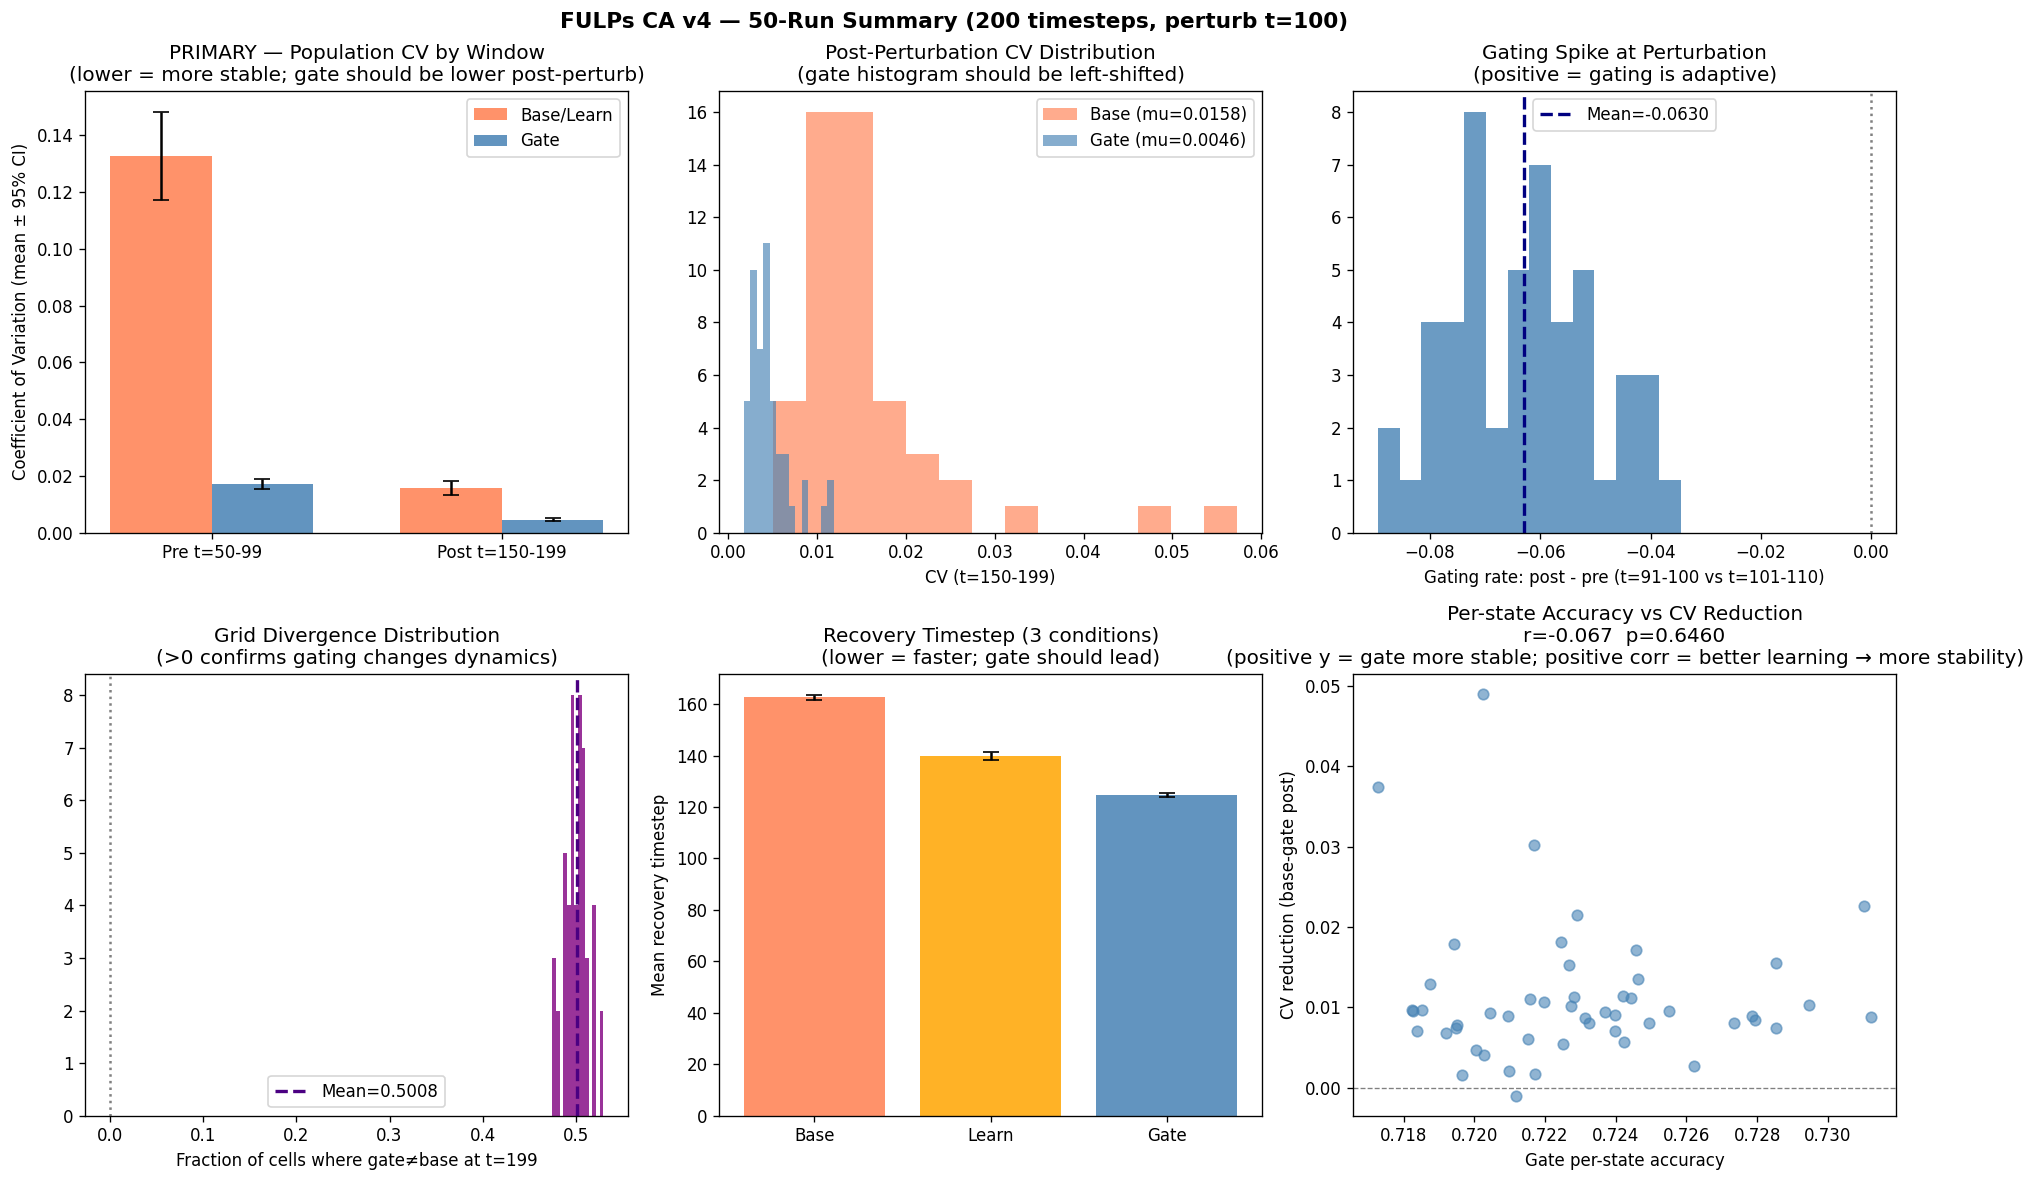

Multi-run chart -> /content/fulps_ca_v4_multirun.png
Full CSV        -> /content/results_50runs_ca_v4.csv
Download both from the Colab file panel.


In [16]:
# ── Cell 15: Multi-Run Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('FULPs CA v4 — 50-Run Summary (200 timesteps, perturb t=100)',
             fontsize=13, fontweight='bold')

def sav(k): return np.array([v for v in all_results[k] if not np.isnan(v)])

# ── PRIMARY: CV post-perturbation (3 conditions) ──────────────────────────────
ax = axes[0,0]
cats = ['Pre t=50-99', 'Post t=150-199']
cv_b_vals = [smean('cv_base_pre'),  smean('cv_base_post')]
cv_g_vals = [smean('cv_gate_pre'),  smean('cv_gate_post')]
ci_b      = [sci('cv_base_pre'),    sci('cv_base_post')]
ci_g      = [sci('cv_gate_pre'),    sci('cv_gate_post')]
x, w      = np.arange(2), 0.35
ax.bar(x-w/2, cv_b_vals, w, yerr=ci_b, capsize=5, label='Base/Learn', color='coral',     alpha=0.85)
ax.bar(x+w/2, cv_g_vals, w, yerr=ci_g, capsize=5, label='Gate',       color='steelblue', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_title('PRIMARY — Population CV by Window\n(lower = more stable; gate should be lower post-perturb)')
ax.set_ylabel('Coefficient of Variation (mean ± 95% CI)'); ax.legend()

# ── CV post-perturbation distribution ─────────────────────────────────────────
ax = axes[0,1]
cv_b_post = sav('cv_base_post'); cv_g_post = sav('cv_gate_post')
if len(cv_b_post)>0: ax.hist(cv_b_post, bins=14, alpha=0.65, color='coral',
                               label=f'Base (mu={cv_b_post.mean():.4f})')
if len(cv_g_post)>0: ax.hist(cv_g_post, bins=14, alpha=0.65, color='steelblue',
                               label=f'Gate (mu={cv_g_post.mean():.4f})')
ax.set_xlabel('CV (t=150-199)')
ax.set_title('Post-Perturbation CV Distribution\n(gate histogram should be left-shifted)')
ax.legend()

# ── Gating spike distribution ─────────────────────────────────────────────────
ax = axes[0,2]
spk_a = sav('gate_spike')
if len(spk_a)>0:
    ax.hist(spk_a, bins=14, color='steelblue', alpha=0.8)
    ax.axvline(spk_a.mean(), color='navy', linestyle='--', lw=2,
               label=f'Mean={spk_a.mean():+.4f}')
    ax.axvline(0, color='gray', linestyle=':', lw=1.5)
ax.set_xlabel('Gating rate: post - pre (t=91-100 vs t=101-110)')
ax.set_title('Gating Spike at Perturbation\n(positive = gating is adaptive)')
ax.legend()

# ── Grid divergence distribution ──────────────────────────────────────────────
ax = axes[1,0]
div_a = sav('grid_divergence')
if len(div_a)>0:
    ax.hist(div_a, bins=14, color='purple', alpha=0.8)
    ax.axvline(div_a.mean(), color='indigo', linestyle='--', lw=2,
               label=f'Mean={div_a.mean():.4f}')
    ax.axvline(0, color='gray', linestyle=':', lw=1.5)
ax.set_xlabel('Fraction of cells where gate≠base at t=199')
ax.set_title('Grid Divergence Distribution\n(>0 confirms gating changes dynamics)')
ax.legend()

# ── Recovery: 3-condition comparison ──────────────────────────────────────────
ax = axes[1,1]
conds = ['Base', 'Learn', 'Gate']
rt_means = [smean('base_recovery_t'), smean('learn_recovery_t'), smean('gate_recovery_t')]
rt_ci    = [sci('base_recovery_t'),   sci('learn_recovery_t'),   sci('gate_recovery_t')]
cols_rc  = ['coral','orange','steelblue']
ax.bar(range(3), rt_means, yerr=rt_ci, capsize=5, color=cols_rc, alpha=0.85)
ax.set_xticks(range(3)); ax.set_xticklabels(conds)
ax.set_title('Recovery Timestep (3 conditions)\n(lower = faster; gate should lead)')
ax.set_ylabel('Mean recovery timestep')

# ── Per-state accuracy vs CV reduction scatter ─────────────────────────────────
ax = axes[1,2]
ps_g   = sav('gate_final_perstate')
cv_red = sav('cv_base_post') - sav('cv_gate_post')
min_len = min(len(ps_g), len(cv_red))
if min_len > 2:
    ax.scatter(ps_g[:min_len], cv_red[:min_len], color='steelblue', alpha=0.6, s=40)
    r, p_r = stats.pearsonr(ps_g[:min_len], cv_red[:min_len])
    ax.set_title(f'Per-state Accuracy vs CV Reduction\nr={r:.3f}  p={p_r:.4f}\n'
                 f'(positive y = gate more stable; positive corr = better learning → more stability)')
    ax.axhline(0, color='gray', linestyle='--', lw=0.8)
ax.set_xlabel('Gate per-state accuracy'); ax.set_ylabel('CV reduction (base-gate post)')

plt.tight_layout()
mr_path = os.path.join(OUT_DIR,'fulps_ca_v4_multirun.png')
plt.savefig(mr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Multi-run chart -> {mr_path}')
print(f'Full CSV        -> {full_path}')
print('Download both from the Colab file panel.')